1. ÎNCĂRCARE DATE

Dimensiune dataset: 9,994 rânduri × 32 coloane
Perioadă: 2014-01-03 → 2017-12-30

Coloane: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'segment', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'order_year', 'order_month', 'order_day', 'ship_year', 'ship_month', 'ship_day', 'shipping_delay', 'profit_per_unit', 'sales_per_unit', 'order_q', 'p_margin', 'is_loss']

Valori lipsă:
Series([], dtype: int64)

Tipuri de date:
row_id                      int64
order_id                      str
order_date         datetime64[us]
ship_date                     str
ship_mode                     str
customer_id                   str
segment                       str
city                          str
state                         str
postal_code                 int64
region                        str
product_id                    str
category       

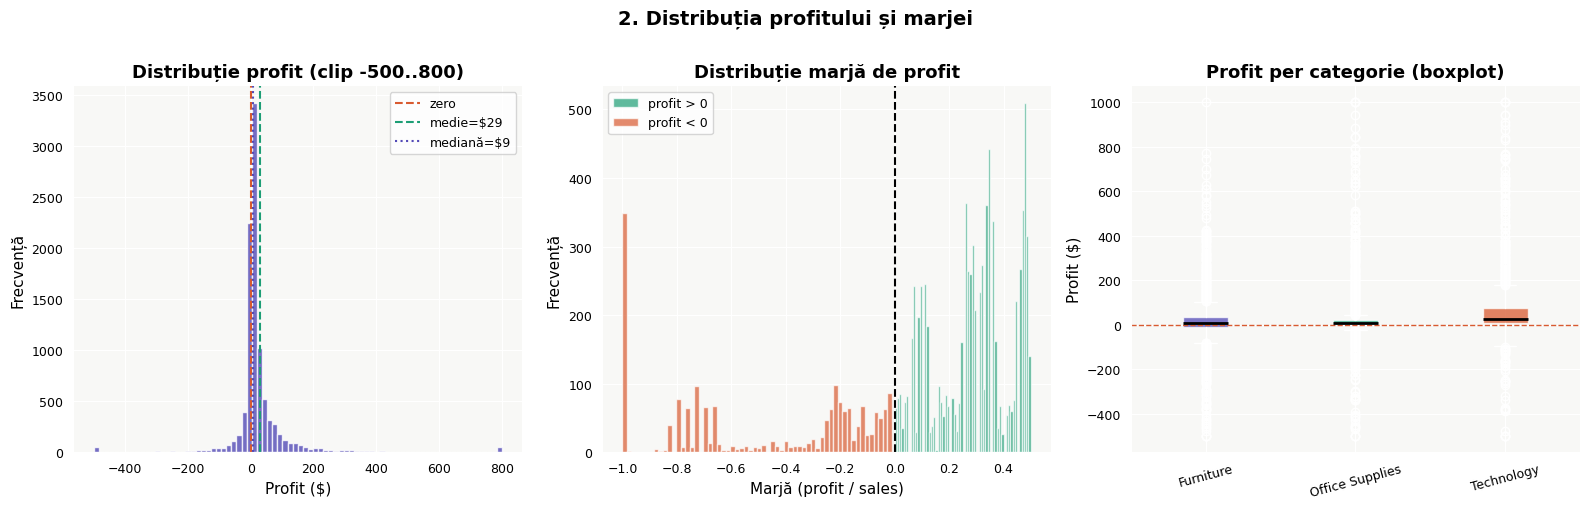

Salvat: eda_01_distributie_profit.png


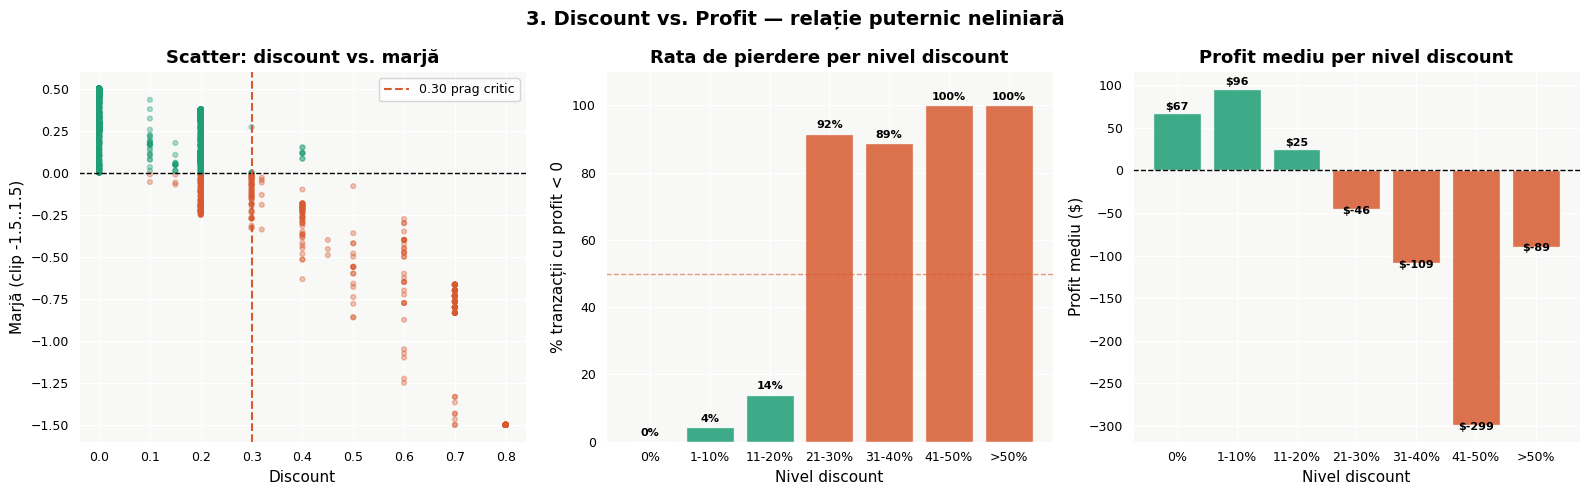

Salvat: eda_02_discount_profit.png


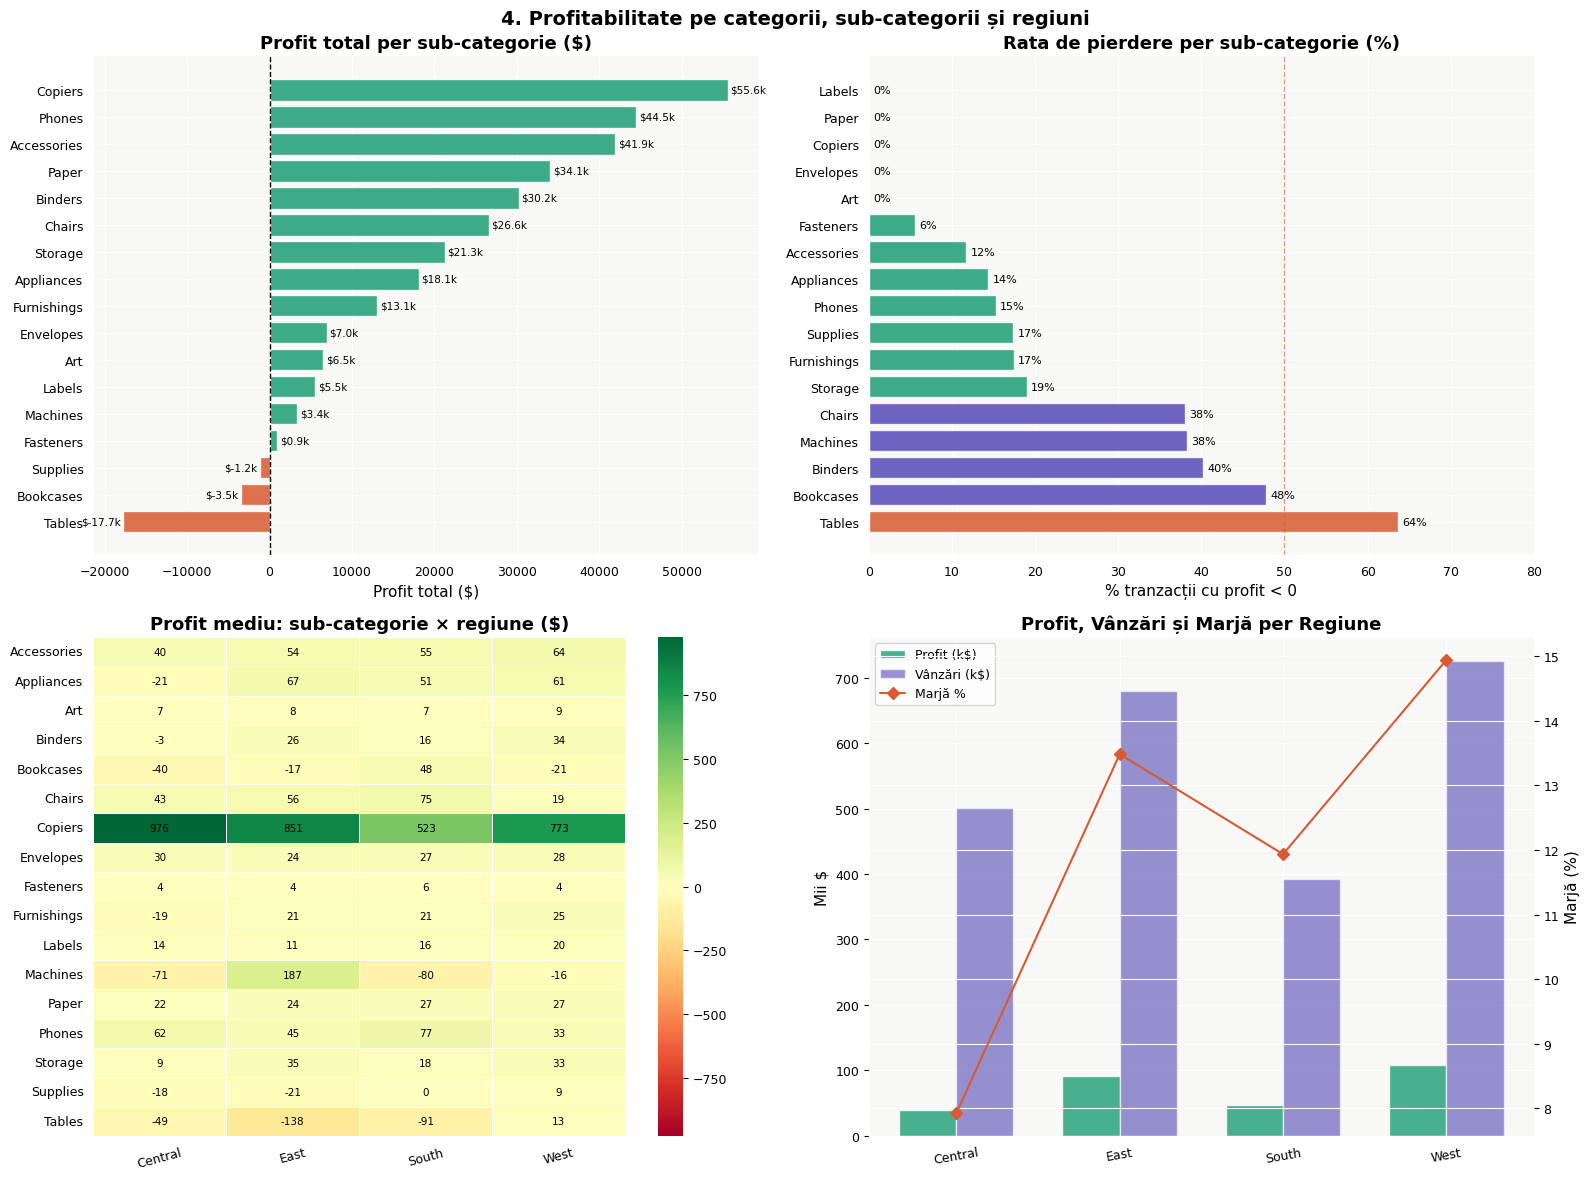

Salvat: eda_03_categorii_regiuni.png


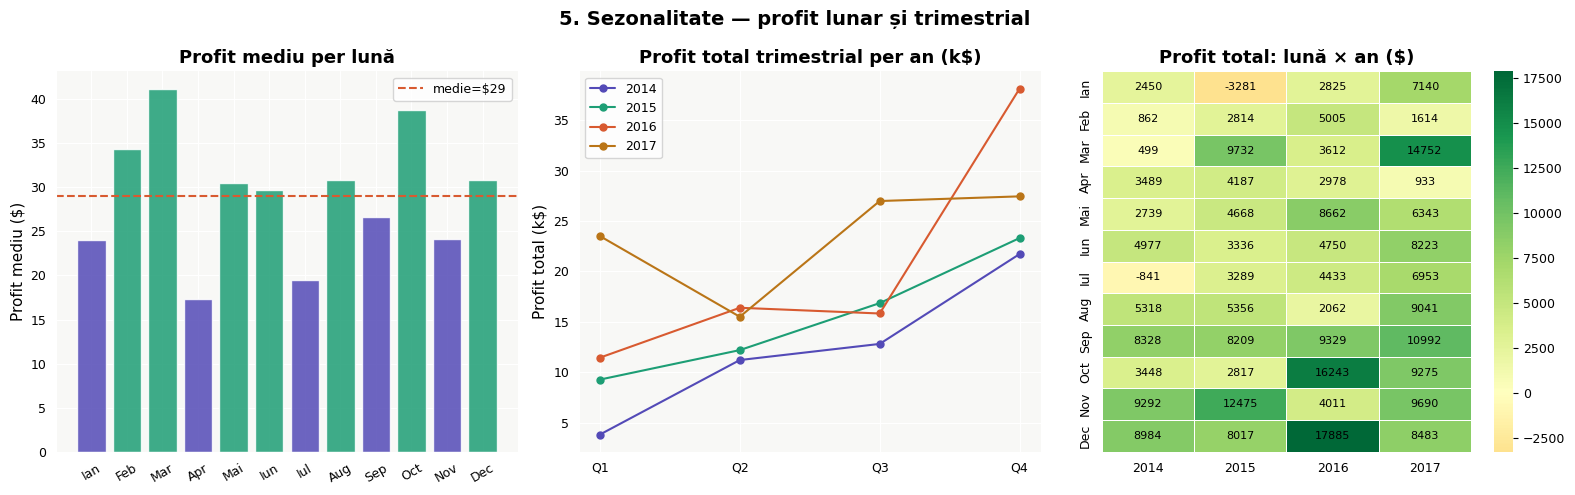

Salvat: eda_04_sezonalitate.png

--- STATISTICI CLIENȚI ---
Total clienți unici: 793
Profit mediu per client: $361
Clienți cu profit total negativ: 155 (19.5%)


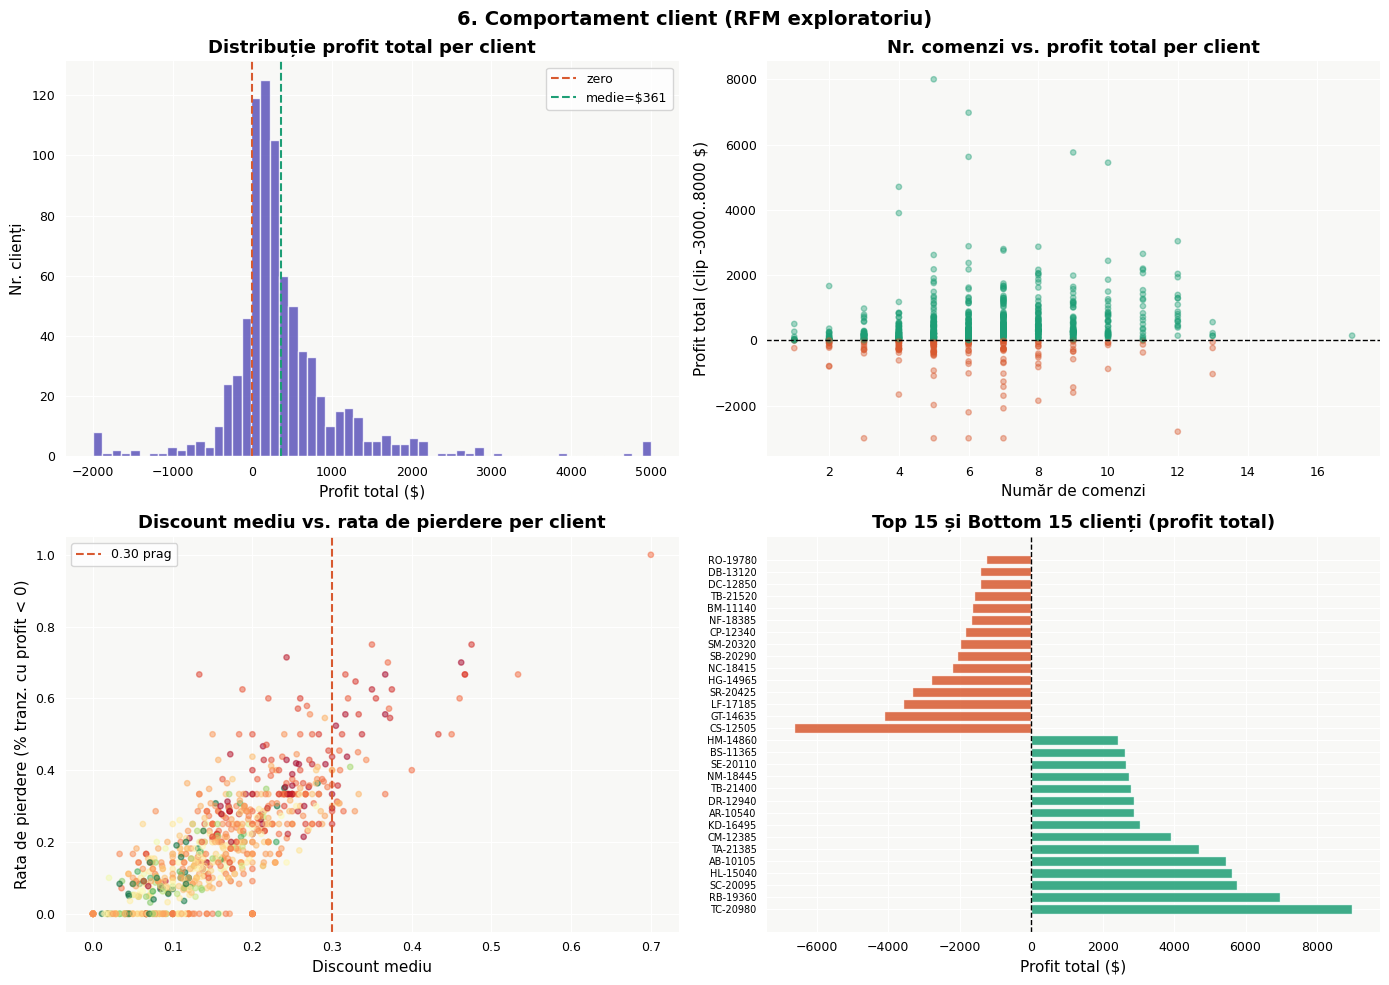

Salvat: eda_05_clienti_rfm.png

--- CORELAȚII CU PROFITUL ---
profit            1.000000
sales             0.479064
p_margin          0.223732
quantity          0.066253
order_year        0.004670
order_month      -0.000502
shipping_delay   -0.004649
discount         -0.219487


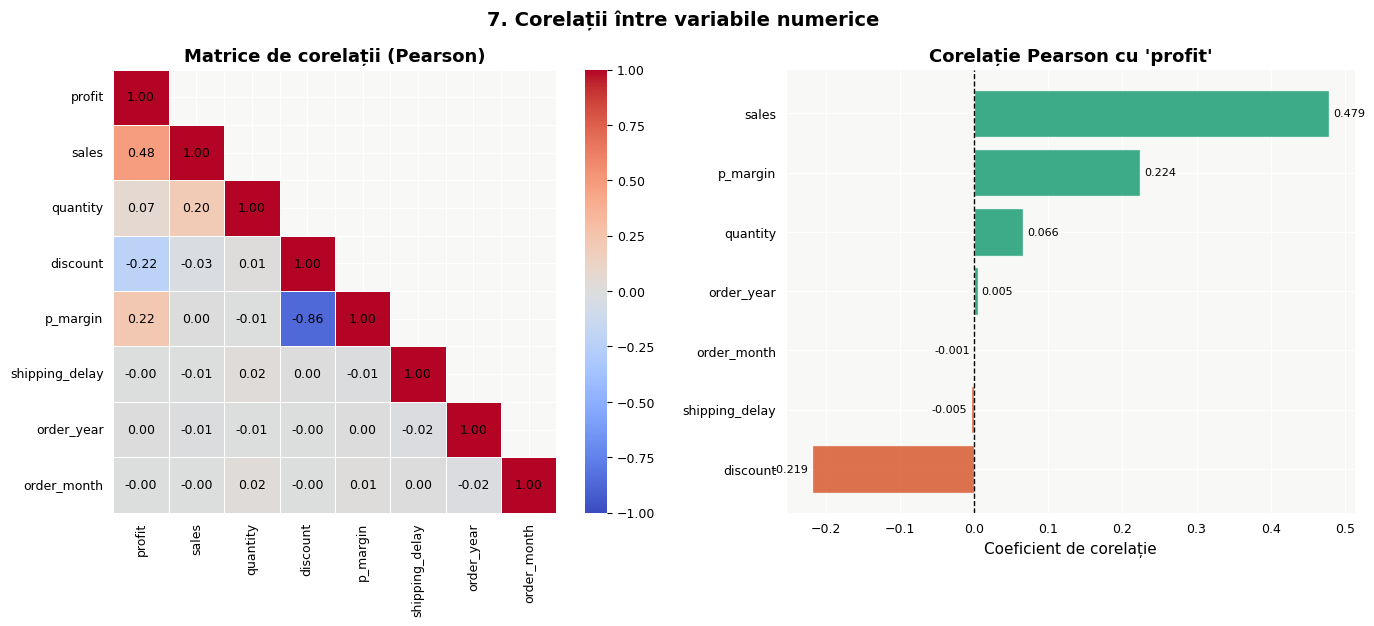

Salvat: eda_06_corelatii.png


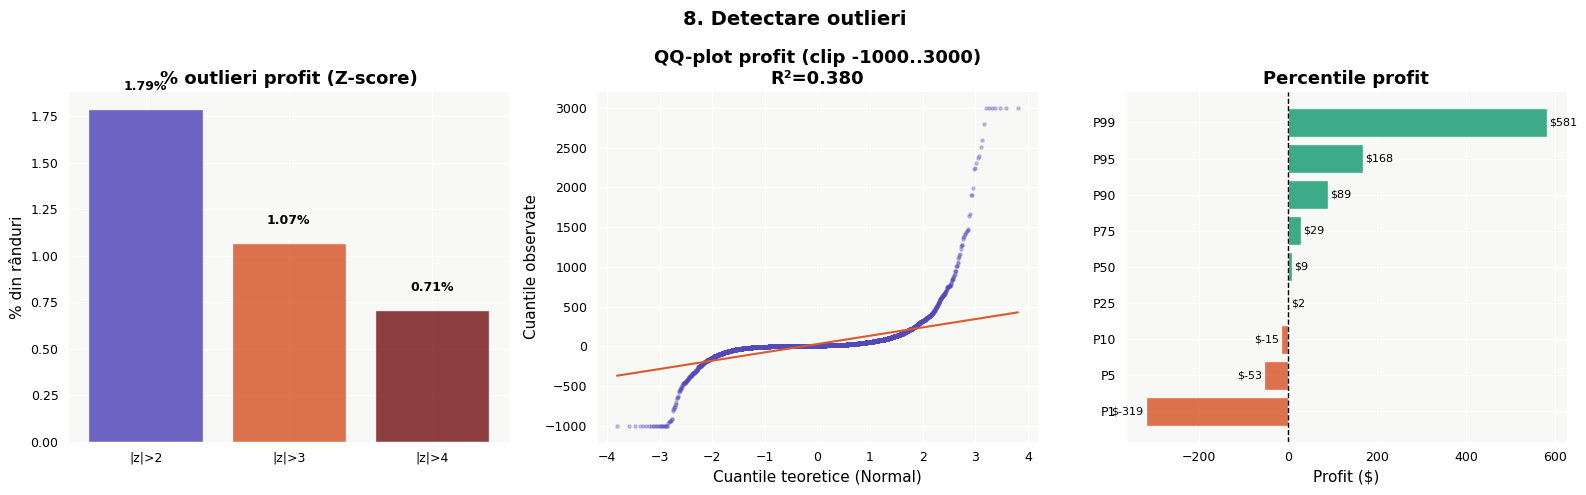

Salvat: eda_07_outlieri.png


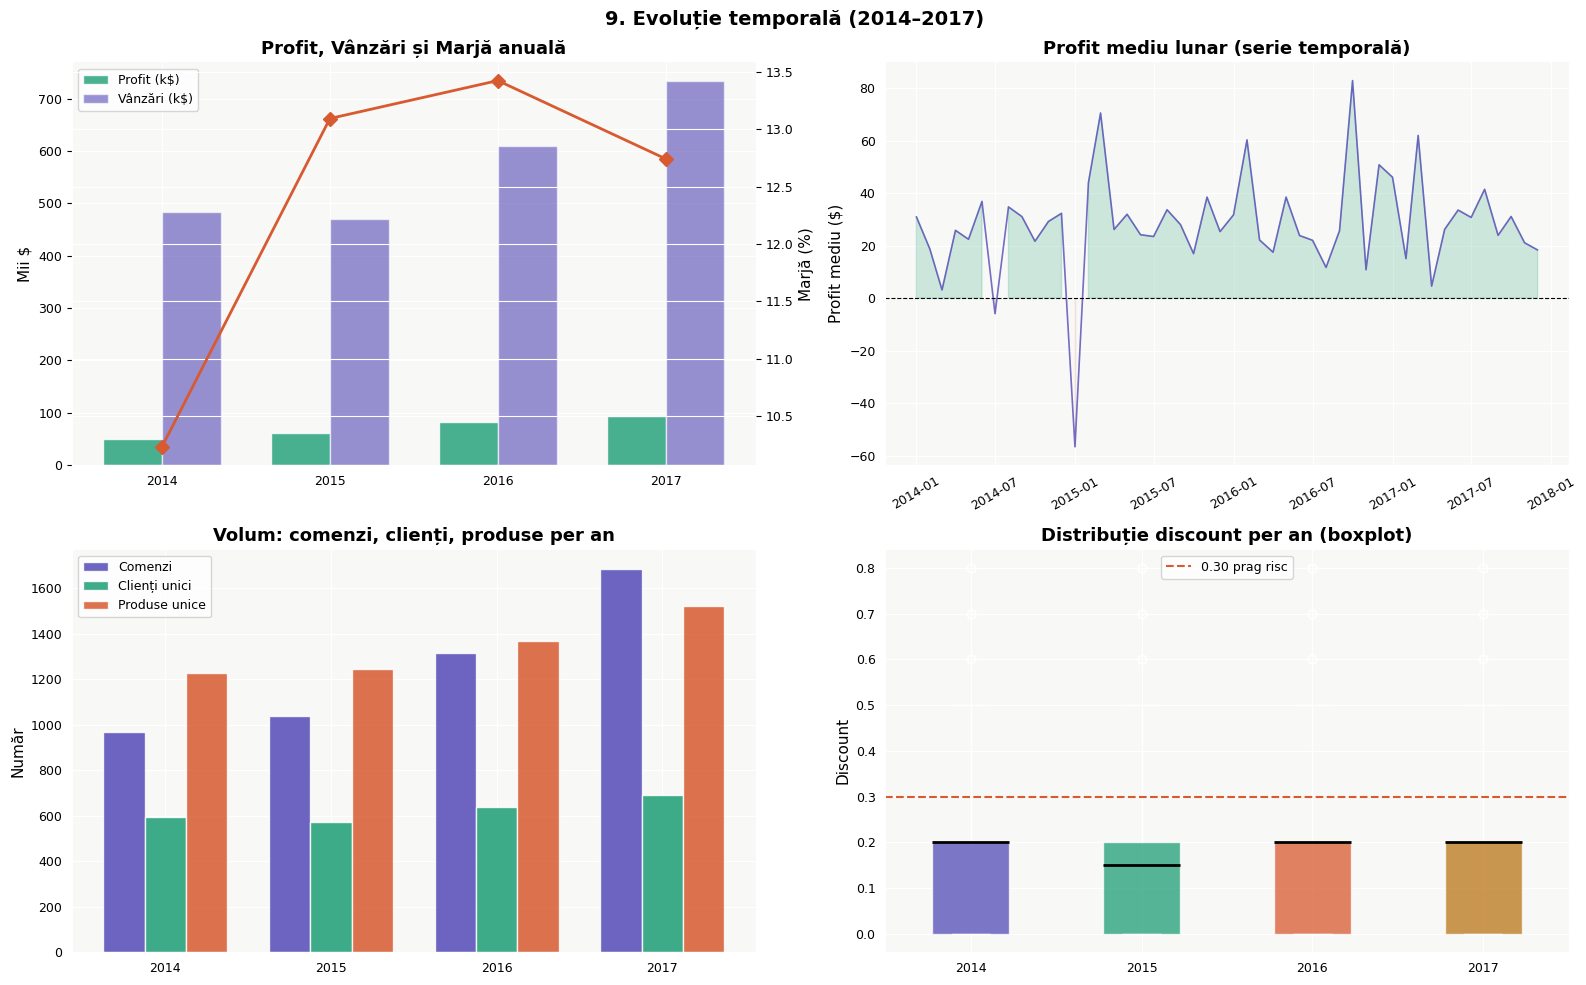

Salvat: eda_08_temporal.png

SUMAR EDA — CONCLUZII CHEIE

Dimensiune dataset : 9,994 tranzacții
Perioadă           : 2014-01-03 → 2017-12-30

PROFIT:
  Total            : $286,397
  Mediu/tranz.     : $28.7
  Mediană          : $8.7
  Std dev          : $234.3
  % tranz. pierdere: 18.7%

DISCOUNT → RISC (critic pentru model!):
  disc = 0.0  → 0% pierdere
  disc = 0.2  → 14% pierdere
  disc ≥ 0.3  → 97% pierdere  ← prag critic!
  disc ≥ 0.5  → 100% pierdere

TOP 3 sub-categorii PROFITABILE:
sub-category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357

TOP 3 sub-categorii NEPROFITABILE:
sub-category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995

Grafice salvate:
  eda_01_distributie_profit.png
  eda_02_discount_profit.png
  eda_03_categorii_regiuni.png
  eda_04_sezonalitate.png
  eda_05_clienti_rfm.png
  eda_06_corelatii.png
  eda_07_outlieri.png
  eda_08_temporal.png



In [1]:
# =============================================================================
# EDA — ANALIZA EXPLORATORIE A DATELOR (Superstore Profit)
# =============================================================================
# Acest script acopera:
# 1. Incarcare si inspectie generala
# 2. Distributia profitului si marjei
# 3. Analiza discountului vs. profit (relatie neliniara)
# 4. Profitabilitate pe categorii, sub-categorii, regiuni
# 5. Sezonalitate (lunar, trimestrial)
# 6. Comportament client (RFM exploratoriu)
# 7. Corelatii intre features numerice
# 8. Detectare outlieri
# 9. Analiza temporala (2014–2017)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# -----------------------------------------------------------------------------
# CONFIG GLOBAL
# -----------------------------------------------------------------------------
plt.rcParams.update({
    'figure.facecolor':      'white',
    'axes.facecolor':        '#F8F8F6',
    'axes.grid':             True,
    'grid.color':            'white',
    'grid.linewidth':        0.8,
    'font.family':           'DejaVu Sans',
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    # --- tot textul → negru ---
    'text.color':            'black',
    'axes.titlecolor':       'black',
    'axes.labelcolor':       'black',
    'xtick.color':           'black',
    'ytick.color':           'black',
    'axes.titlesize':        13,
    'axes.titleweight':      'bold',
    'axes.labelsize':        11,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    # --- legendă → negru ---
    'legend.fontsize':       9,
    'legend.labelcolor':     'black',
    'legend.title_fontsize': 9,
    'legend.edgecolor':      '#CCCCCC',
    'legend.facecolor':      'white',
    # --- suptitle → negru (via text.color de mai sus) ---
})

PALETTE_CAT  = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517']  # purple, teal, coral, amber
PALETTE_DIV  = 'RdYlGn'
COLOR_POS    = '#1D9E75'
COLOR_NEG    = '#D85A30'
COLOR_NEUT   = '#534AB7'

# -----------------------------------------------------------------------------
# 1. ÎNCĂRCARE ȘI INSPECȚIE GENERALĂ
# -----------------------------------------------------------------------------
print("=" * 70)
print("1. ÎNCĂRCARE DATE")
print("=" * 70)

df = pd.read_csv(r'..\data\processed\df_preprocessed.csv')
df['order_date']  = pd.to_datetime(df['order_date'])
df['order_year']  = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_q']     = df['order_date'].dt.quarter
df['p_margin']    = df['profit'] / (df['sales'] + 1e-5)
df['is_loss']     = (df['profit'] < 0).astype(int)

print(f"\nDimensiune dataset: {df.shape[0]:,} rânduri × {df.shape[1]} coloane")
print(f"Perioadă: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"\nColoane: {list(df.columns)}")
print(f"\nValori lipsă:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTipuri de date:\n{df.dtypes}")

print("\n--- STATISTICI DESCRIPTIVE (profit, sales, discount) ---")
print(df[['profit', 'sales', 'discount', 'p_margin']].describe().round(3).to_string())

print(f"\nTotal profit:  ${df['profit'].sum():,.0f}")
print(f"Total vânzări: ${df['sales'].sum():,.0f}")
print(f"Marjă globală: {df['profit'].sum() / df['sales'].sum() * 100:.2f}%")
print(f"Tranzacții cu pierdere: {df['is_loss'].mean()*100:.1f}%  ({df['is_loss'].sum():,})")


# =============================================================================
# 2. DISTRIBUȚIA PROFITULUI ȘI MARJEI
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("2. Distribuția profitului și marjei", fontsize=14, fontweight='bold', color='black', y=1.01)

# 2a. Histogram profit
ax = axes[0]
ax.hist(df['profit'].clip(-500, 800), bins=80, color=COLOR_NEUT, alpha=0.8, edgecolor='white')
ax.axvline(0,                        color=COLOR_NEG, lw=1.5, ls='--', label='zero')
ax.axvline(df['profit'].mean(),      color=COLOR_POS, lw=1.5, ls='--', label=f"medie=${df['profit'].mean():.0f}")
ax.axvline(df['profit'].median(),    color=COLOR_NEUT, lw=1.5, ls=':', label=f"mediană=${df['profit'].median():.0f}")
ax.set_title("Distribuție profit (clip -500..800)")
ax.set_xlabel("Profit ($)")
ax.set_ylabel("Frecvență")
ax.legend()

# 2b. Histogram marjă (clip -1..1)
ax = axes[1]
margin_clip = df['p_margin'].clip(-1, 1)
ax.hist(margin_clip[df['is_loss'] == 0], bins=60, color=COLOR_POS, alpha=0.7, label='profit > 0')
ax.hist(margin_clip[df['is_loss'] == 1], bins=60, color=COLOR_NEG, alpha=0.7, label='profit < 0')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_title("Distribuție marjă de profit")
ax.set_xlabel("Marjă (profit / sales)")
ax.set_ylabel("Frecvență")
ax.legend()

# 2c. Boxplot profit pe categorii
ax = axes[2]
cats = df['category'].unique()
data_box = [df[df['category'] == c]['profit'].clip(-500, 1000) for c in cats]
bp = ax.boxplot(data_box, patch_artist=True, medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], PALETTE_CAT):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax.set_xticklabels(cats, rotation=15)
ax.axhline(0, color=COLOR_NEG, lw=1, ls='--')
ax.set_title("Profit per categorie (boxplot)")
ax.set_ylabel("Profit ($)")

plt.tight_layout()
plt.savefig('eda_graphs/eda_01_distributie_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_01_distributie_profit.png")


# =============================================================================
# 3. ANALIZA DISCOUNT vs. PROFIT (relație neliniară critică)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("3. Discount vs. Profit — relație puternic neliniară", fontsize=14, fontweight='bold', color='black')

# 3a. Scatter discount vs p_margin
ax = axes[0]
sample = df.sample(min(3000, len(df)), random_state=42)
colors = [COLOR_POS if v >= 0 else COLOR_NEG for v in sample['p_margin']]
ax.scatter(sample['discount'], sample['p_margin'].clip(-1.5, 1.5),
           c=colors, alpha=0.35, s=12)
ax.axhline(0, color='black', lw=1, ls='--')
ax.axvline(0.3, color=COLOR_NEG, lw=1.5, ls='--', label='0.30 prag critic')
ax.set_title("Scatter: discount vs. marjă")
ax.set_xlabel("Discount")
ax.set_ylabel("Marjă (clip -1.5..1.5)")
ax.legend()

# 3b. Rata de pierdere per nivel de discount (grupat)
ax = axes[1]
df['disc_bin'] = pd.cut(df['discount'],
                         bins=[-0.001, 0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
                         labels=['0%','1-10%','11-20%','21-30%','31-40%','41-50%','>50%'])
loss_rate = df.groupby('disc_bin', observed=True)['is_loss'].mean() * 100
bars = ax.bar(loss_rate.index, loss_rate.values,
              color=[COLOR_POS if v < 20 else COLOR_NEG if v > 60 else COLOR_NEUT for v in loss_rate.values],
              edgecolor='white', alpha=0.85)
for bar, val in zip(bars, loss_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(50, color=COLOR_NEG, lw=1, ls='--', alpha=0.6)
ax.set_title("Rata de pierdere per nivel discount")
ax.set_xlabel("Nivel discount")
ax.set_ylabel("% tranzacții cu profit < 0")
ax.set_ylim(0, 110)

# 3c. Profit mediu per nivel discount
ax = axes[2]
profit_disc = df.groupby('disc_bin', observed=True)['profit'].mean()
bars = ax.bar(profit_disc.index, profit_disc.values,
              color=[COLOR_POS if v >= 0 else COLOR_NEG for v in profit_disc.values],
              edgecolor='white', alpha=0.85)
for bar, val in zip(bars, profit_disc.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (2 if val >= 0 else -8),
            f'${val:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title("Profit mediu per nivel discount")
ax.set_xlabel("Nivel discount")
ax.set_ylabel("Profit mediu ($)")

plt.tight_layout()
plt.savefig('eda_graphs/eda_02_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_02_discount_profit.png")


# =============================================================================
# 4. PROFITABILITATE PE CATEGORII, SUB-CATEGORII, REGIUNI
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("4. Profitabilitate pe categorii, sub-categorii și regiuni", fontsize=14, fontweight='bold', color='black')

# 4a. Sub-categorie — profit total
ax = axes[0, 0]
sub_profit = (df.groupby('sub-category')['profit']
                .sum()
                .sort_values())
colors_sub = [COLOR_POS if v >= 0 else COLOR_NEG for v in sub_profit.values]
bars = ax.barh(sub_profit.index, sub_profit.values, color=colors_sub, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1, ls='--')
for bar, val in zip(bars, sub_profit.values):
    ax.text(val + (300 if val >= 0 else -300), bar.get_y() + bar.get_height()/2,
            f'${val/1000:.1f}k', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_title("Profit total per sub-categorie ($)")
ax.set_xlabel("Profit total ($)")

# 4b. Sub-categorie — rata de pierdere
ax = axes[0, 1]
sub_loss = (df.groupby('sub-category')['is_loss']
              .mean()
              .sort_values(ascending=False) * 100)
colors_loss = [COLOR_NEG if v > 50 else COLOR_NEUT if v > 20 else COLOR_POS for v in sub_loss.values]
bars = ax.barh(sub_loss.index, sub_loss.values, color=colors_loss, alpha=0.85, edgecolor='white')
ax.axvline(50, color=COLOR_NEG, lw=1, ls='--', alpha=0.6)
for bar, val in zip(bars, sub_loss.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', ha='left', fontsize=8)
ax.set_title("Rata de pierdere per sub-categorie (%)")
ax.set_xlabel("% tranzacții cu profit < 0")
ax.set_xlim(0, 80)

# 4c. Heatmap profit mediu: sub-categorie × regiune
ax = axes[1, 0]
pivot = df.pivot_table(values='profit', index='sub-category', columns='region', aggfunc='mean')
vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            annot_kws={'size': 7.5, 'color': 'black'})
ax.set_title("Profit mediu: sub-categorie × regiune ($)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='x', rotation=15)

# 4d. Regiune: profit total + vânzări
ax = axes[1, 1]
reg = df.groupby('region').agg(profit=('profit','sum'), sales=('sales','sum')).reset_index()
reg['margin'] = reg['profit'] / reg['sales'] * 100
x = np.arange(len(reg))
w = 0.35
b1 = ax.bar(x - w/2, reg['profit']/1000, width=w, color=COLOR_POS, alpha=0.8, label='Profit (k$)')
b2 = ax.bar(x + w/2, reg['sales']/1000,  width=w, color=COLOR_NEUT, alpha=0.6, label='Vânzări (k$)')
ax2 = ax.twinx()
ax2.plot(x, reg['margin'], 'D-', color=COLOR_NEG, ms=6, lw=1.5, label='Marjă %')
ax2.set_ylabel("Marjă (%)", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax.set_xticks(x)
ax.set_xticklabels(reg['region'], rotation=10)
ax.set_title("Profit, Vânzări și Marjă per Regiune")
ax.set_ylabel("Mii $")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('eda_graphs/eda_03_categorii_regiuni.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_03_categorii_regiuni.png")


# =============================================================================
# 5. SEZONALITATE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("5. Sezonalitate — profit lunar și trimestrial", fontsize=14, fontweight='bold', color='black')

# 5a. Profit mediu per lună
ax = axes[0]
monthly = df.groupby('order_month')['profit'].mean()
month_labels = ['Ian','Feb','Mar','Apr','Mai','Iun','Iul','Aug','Sep','Oct','Nov','Dec']
colors_m = [COLOR_POS if v >= monthly.mean() else COLOR_NEUT for v in monthly.values]
ax.bar(range(1, 13), monthly.values, color=colors_m, alpha=0.85, edgecolor='white')
ax.axhline(monthly.mean(), color=COLOR_NEG, lw=1.5, ls='--', label=f'medie=${monthly.mean():.0f}')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)
ax.set_title("Profit mediu per lună")
ax.set_ylabel("Profit mediu ($)")
ax.legend()

# 5b. Profit total per trimestru per an
ax = axes[1]
qt = df.groupby(['order_year', 'order_q'])['profit'].sum().reset_index()
qt['label'] = qt['order_year'].astype(str) + '-Q' + qt['order_q'].astype(str)
colors_yr = {2014: PALETTE_CAT[0], 2015: PALETTE_CAT[1], 2016: PALETTE_CAT[2], 2017: PALETTE_CAT[3]}
for yr in sorted(qt['order_year'].unique()):
    sub = qt[qt['order_year'] == yr]
    ax.plot(sub['order_q'], sub['profit']/1000, 'o-',
            color=colors_yr.get(yr, 'gray'), label=str(yr), ms=5, lw=1.5)
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.set_title("Profit total trimestrial per an (k$)")
ax.set_ylabel("Profit total (k$)")
ax.legend()

# 5c. Heatmap: lună × an
ax = axes[2]
heat = df.pivot_table(values='profit', index='order_month', columns='order_year', aggfunc='sum')
heat.index = month_labels
sns.heatmap(heat, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            annot_kws={'size': 8, 'color': 'black'})
ax.set_title("Profit total: lună × an ($)")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig('eda_graphs/eda_04_sezonalitate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_04_sezonalitate.png")


# =============================================================================
# 6. ANALIZA CLIENȚILOR (RFM EXPLORATORIU)
# =============================================================================
print("\n--- STATISTICI CLIENȚI ---")
cust = df.groupby('customer_id').agg(
    total_profit  = ('profit', 'sum'),
    total_sales   = ('sales', 'sum'),
    n_orders      = ('order_id', 'nunique'),
    avg_discount  = ('discount', 'mean'),
    loss_rate     = ('is_loss', 'mean'),
    first_year    = ('order_year', 'min'),
    last_year     = ('order_year', 'max'),
).reset_index()
cust['avg_margin'] = cust['total_profit'] / (cust['total_sales'] + 1e-5)

print(f"Total clienți unici: {len(cust)}")
print(f"Profit mediu per client: ${cust['total_profit'].mean():,.0f}")
print(f"Clienți cu profit total negativ: {(cust['total_profit'] < 0).sum()} "
      f"({(cust['total_profit'] < 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("6. Comportament client (RFM exploratoriu)", fontsize=14, fontweight='bold', color='black')

# 6a. Distribuție profit per client
ax = axes[0, 0]
ax.hist(cust['total_profit'].clip(-2000, 5000), bins=60,
        color=COLOR_NEUT, alpha=0.8, edgecolor='white')
ax.axvline(0, color=COLOR_NEG, lw=1.5, ls='--', label='zero')
ax.axvline(cust['total_profit'].mean(), color=COLOR_POS, lw=1.5, ls='--',
           label=f"medie=${cust['total_profit'].mean():.0f}")
ax.set_title("Distribuție profit total per client")
ax.set_xlabel("Profit total ($)")
ax.set_ylabel("Nr. clienți")
ax.legend()

# 6b. Scatter: nr. comenzi vs. profit total
ax = axes[0, 1]
colors_c = [COLOR_POS if v >= 0 else COLOR_NEG for v in cust['total_profit']]
ax.scatter(cust['n_orders'], cust['total_profit'].clip(-3000, 8000),
           c=colors_c, alpha=0.4, s=15)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title("Nr. comenzi vs. profit total per client")
ax.set_xlabel("Număr de comenzi")
ax.set_ylabel("Profit total (clip -3000..8000 $)")

# 6c. Rata de pierdere vs. discount mediu
ax = axes[1, 0]
ax.scatter(cust['avg_discount'], cust['loss_rate'],
           c=cust['total_profit'], cmap='RdYlGn', alpha=0.5, s=15,
           vmin=-500, vmax=2000)
ax.axvline(0.3, color=COLOR_NEG, lw=1.5, ls='--', label='0.30 prag')
ax.set_title("Discount mediu vs. rata de pierdere per client")
ax.set_xlabel("Discount mediu")
ax.set_ylabel("Rata de pierdere (% tranz. cu profit < 0)")
ax.legend()

# 6d. Top 15 clienți și bottom 15 clienți după profit total
ax = axes[1, 1]
top10    = cust.nlargest(15, 'total_profit')[['customer_id','total_profit']]
bottom10 = cust.nsmallest(15, 'total_profit')[['customer_id','total_profit']]
combined = pd.concat([top10, bottom10])
colors_tb = [COLOR_POS if v >= 0 else COLOR_NEG for v in combined['total_profit']]
ax.barh(combined['customer_id'], combined['total_profit'],
        color=colors_tb, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title("Top 15 și Bottom 15 clienți (profit total)")
ax.set_xlabel("Profit total ($)")
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('eda_graphs/eda_05_clienti_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_05_clienti_rfm.png")


# =============================================================================
# 7. MATRICE DE CORELAȚII
# =============================================================================
print("\n--- CORELAȚII CU PROFITUL ---")
num_cols = ['profit', 'sales', 'quantity', 'discount', 'p_margin',
            'shipping_delay', 'order_year', 'order_month']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()
print(corr['profit'].sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("7. Corelații între variabile numerice", fontsize=14, fontweight='bold', color='black')

# 7a. Heatmap corelații
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            mask=mask, square=True, annot_kws={'size': 9, 'color': 'black'})
ax.set_title("Matrice de corelații (Pearson)")

# 7b. Bar chart: corelații cu profitul
ax = axes[1]
corr_profit = corr['profit'].drop('profit').sort_values()
colors_corr = [COLOR_POS if v >= 0 else COLOR_NEG for v in corr_profit.values]
ax.barh(corr_profit.index, corr_profit.values, color=colors_corr, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1, ls='--')
for i, (idx, val) in enumerate(corr_profit.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_title("Corelație Pearson cu 'profit'")
ax.set_xlabel("Coeficient de corelație")

plt.tight_layout()
plt.savefig('eda_graphs/eda_06_corelatii.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_06_corelatii.png")


# =============================================================================
# 8. DETECTARE OUTLIERI
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("8. Detectare outlieri", fontsize=14, fontweight='bold', color='black')

# 8a. Z-score profit
ax = axes[0]
z_profit = np.abs(stats.zscore(df['profit']))
thresholds = [2, 3, 4]
pcts = [(z_profit > t).mean() * 100 for t in thresholds]
ax.bar([f'|z|>{t}' for t in thresholds], pcts,
       color=[COLOR_NEUT, COLOR_NEG, '#7A1F1F'], alpha=0.85, edgecolor='white')
for i, v in enumerate(pcts):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title("% outlieri profit (Z-score)")
ax.set_ylabel("% din rânduri")

# 8b. Distribuție QQ pentru profit
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(df['profit'].clip(-1000, 3000))
ax.scatter(osm, osr, color=COLOR_NEUT, alpha=0.3, s=5)
ax.plot(osm, slope * np.array(osm) + intercept, color=COLOR_NEG, lw=1.5)
ax.set_title(f"QQ-plot profit (clip -1000..3000)\nR²={r**2:.3f}")
ax.set_xlabel("Cuantile teoretice (Normal)")
ax.set_ylabel("Cuantile observate")

# 8c. Percentile extreme
ax = axes[2]
pcts_vals = [1, 5, 10, 25, 50, 75, 90, 95, 99]
p_vals = [df['profit'].quantile(p/100) for p in pcts_vals]
colors_pv = [COLOR_POS if v >= 0 else COLOR_NEG for v in p_vals]
ax.barh([f'P{p}' for p in pcts_vals], p_vals, color=colors_pv, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1, ls='--')
for i, v in enumerate(p_vals):
    ax.text(v + (5 if v >= 0 else -5), i,
            f'${v:.0f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax.set_title("Percentile profit")
ax.set_xlabel("Profit ($)")

plt.tight_layout()
plt.savefig('eda_graphs/eda_07_outlieri.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_07_outlieri.png")


# =============================================================================
# 9. ANALIZA TEMPORALĂ (2014-2017)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("9. Evoluție temporală (2014–2017)", fontsize=14, fontweight='bold', color='black')

# 9a. Profit și vânzări anuale
ax = axes[0, 0]
annual = df.groupby('order_year').agg(profit=('profit','sum'), sales=('sales','sum')).reset_index()
annual['margin'] = annual['profit'] / annual['sales'] * 100
x = annual['order_year']
w = 0.35
ax.bar(x - w/2, annual['profit']/1000, width=w, color=COLOR_POS, alpha=0.8, label='Profit (k$)')
ax.bar(x + w/2, annual['sales']/1000,  width=w, color=COLOR_NEUT, alpha=0.6, label='Vânzări (k$)')
ax2 = ax.twinx()
ax2.plot(x, annual['margin'], 'D-', color=COLOR_NEG, ms=7, lw=2, label='Marjă %')
ax2.set_ylabel("Marjă (%)", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax.set_title("Profit, Vânzări și Marjă anuală")
ax.set_ylabel("Mii $")
ax.legend(loc='upper left')
ax.set_xticks(x)

# 9b. Evoluție lunară a profitului mediu (toate perioadele)
ax = axes[0, 1]
df_sorted = df.sort_values('order_date')
monthly_ts = df_sorted.groupby(df_sorted['order_date'].dt.to_period('M'))['profit'].mean()
monthly_ts.index = monthly_ts.index.to_timestamp()
ax.plot(monthly_ts.index, monthly_ts.values, color=COLOR_NEUT, lw=1.2, alpha=0.8)
ax.fill_between(monthly_ts.index,
                monthly_ts.values, 0,
                where=(monthly_ts.values >= 0), alpha=0.2, color=COLOR_POS)
ax.fill_between(monthly_ts.index,
                monthly_ts.values, 0,
                where=(monthly_ts.values < 0), alpha=0.2, color=COLOR_NEG)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title("Profit mediu lunar (serie temporală)")
ax.set_ylabel("Profit mediu ($)")
ax.tick_params(axis='x', rotation=30)

# 9c. Nr. comenzi și clienți unici per an
ax = axes[1, 0]
vol = df.groupby('order_year').agg(
    n_orders   = ('order_id', 'nunique'),
    n_customers= ('customer_id', 'nunique'),
    n_products = ('product_id', 'nunique'),
).reset_index()
x = np.arange(len(vol))
ax.bar(x - 0.25, vol['n_orders'],    width=0.25, color=PALETTE_CAT[0], alpha=0.85, label='Comenzi')
ax.bar(x       , vol['n_customers'], width=0.25, color=PALETTE_CAT[1], alpha=0.85, label='Clienți unici')
ax.bar(x + 0.25, vol['n_products'],  width=0.25, color=PALETTE_CAT[2], alpha=0.85, label='Produse unice')
ax.set_xticks(x)
ax.set_xticklabels(vol['order_year'])
ax.set_title("Volum: comenzi, clienți, produse per an")
ax.set_ylabel("Număr")
ax.legend()

# 9d. Distribuție discount per an (boxplot)
ax = axes[1, 1]
years = sorted(df['order_year'].unique())
data_disc = [df[df['order_year'] == y]['discount'] for y in years]
bp = ax.boxplot(data_disc, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], PALETTE_CAT):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax.set_xticklabels(years)
ax.axhline(0.3, color=COLOR_NEG, lw=1.5, ls='--', label='0.30 prag risc')
ax.set_title("Distribuție discount per an (boxplot)")
ax.set_ylabel("Discount")
ax.legend()

plt.tight_layout()
plt.savefig('eda_graphs/eda_08_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: eda_08_temporal.png")


# =============================================================================
# SUMAR FINAL
# =============================================================================
print("\n" + "=" * 70)
print("SUMAR EDA — CONCLUZII CHEIE")
print("=" * 70)
print(f"""
Dimensiune dataset : {df.shape[0]:,} tranzacții
Perioadă           : {df['order_date'].min().date()} → {df['order_date'].max().date()}

PROFIT:
  Total            : ${df['profit'].sum():,.0f}
  Mediu/tranz.     : ${df['profit'].mean():.1f}
  Mediană          : ${df['profit'].median():.1f}
  Std dev          : ${df['profit'].std():.1f}
  % tranz. pierdere: {df['is_loss'].mean()*100:.1f}%

DISCOUNT → RISC (critic pentru model!):
  disc = 0.0  → {df[df['discount']==0.0]['is_loss'].mean()*100:.0f}% pierdere
  disc = 0.2  → {df[(df['discount']>=0.18)&(df['discount']<=0.22)]['is_loss'].mean()*100:.0f}% pierdere
  disc ≥ 0.3  → {df[df['discount']>=0.3]['is_loss'].mean()*100:.0f}% pierdere  ← prag critic!
  disc ≥ 0.5  → {df[df['discount']>=0.5]['is_loss'].mean()*100:.0f}% pierdere

TOP 3 sub-categorii PROFITABILE:
{df.groupby('sub-category')['profit'].sum().nlargest(3).to_string()}

TOP 3 sub-categorii NEPROFITABILE:
{df.groupby('sub-category')['profit'].sum().nsmallest(3).to_string()}

Grafice salvate:
  eda_01_distributie_profit.png
  eda_02_discount_profit.png
  eda_03_categorii_regiuni.png
  eda_04_sezonalitate.png
  eda_05_clienti_rfm.png
  eda_06_corelatii.png
  eda_07_outlieri.png
  eda_08_temporal.png
""")
